# **Лабораторна робота №2. Регресійний аналіз даних. Кореляція**
**Дисципліна:** Інтелектуальний аналіз даних (ІАД)  
**Виконав:** студент групи КН-2327б Багрій-Белз Андрій  

---
### Мета роботи:
Опанувати математичні та програмні засоби парного лінійного регресійного та кореляційного аналізу у Python. Навчитися визначати коефіцієнт кореляції Пірсона, знаходити параметри прямої регресії ($a, b$) методом найменших квадратів, оцінювати якість апроксимації ($R^2$, MSE, RMSE, $p$-value) та перевіряти базові передумови регресійного моделювання через діагностику залишків.

## 1. Імпорт бібліотек та налаштування графічного середовища
**Мета дії:** Підключити наукові бібліотеки `pandas`, `numpy`, `scipy.stats`, `sklearn`, `matplotlib` та `seaborn` для обчислень і побудови графіків.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

# Налаштування візуалізації
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 13,
    'figure.titlesize': 14,
    'figure.autolayout': True
})
print('Бібліотеки успішно завантажено. Середовище готове до аналізу.')

Бібліотеки успішно завантажено. Середовище готове до аналізу.


## 2. Завантаження та первинний аналіз даних anaconda.dat (Частина 1)
**Мета дії:** Зчитати дані вимірювань анаконд (довжина `X`, маса `Y`, стать `Gender`) за відносним шляхом без прив'язки до локального каталогу або Colab `/content/`. Вивести розмірність, типи даних та перші рядки.
$$\rightarrow$$ **Висновок:** Набір даних успішно імпортовано; пропущених значень немає, типи числових стовпців визначено коректно.

In [2]:
# Завантаження даних anaconda.dat (підтримує локальний запуск та Colab)
file_name = 'anaconda.dat'
if not os.path.exists(file_name):
    if os.path.exists('Lab_2/anaconda.dat'):
        file_name = 'Lab_2/anaconda.dat'
    elif os.path.exists('/content/anaconda.dat'):
        file_name = '/content/anaconda.dat'

df = pd.read_csv(file_name, sep=r'\s+', names=['X', 'Y', 'Gender'], header=None)
print('Розмірність вибірки (рядків, колонок):', df.shape)
print('\nТипи даних:')
print(df.dtypes)
print('\nПерші 5 рядків таблиці:')
print(df.head())

Розмірність вибірки (рядків, колонок): (56, 3)

Типи даних:
X         float64
Y         float64
Gender        str

Перші 5 рядків таблиці:
       X     Y Gender
0  271.0  18.5      F
1  477.0  82.5      F
2  306.3  23.4      F
3  365.3  33.5      F
4  466.0  69.0      F


## 3. Кодування статі та розрахунок кореляційної матриці Пірсона
**Мета дії:** Перетворити якісну ознаку `Gender` на фіктивну числову змінну (`M` $\rightarrow 0$, `F` $\rightarrow 1$) та обчислити матрицю парних коефіцієнтів кореляції Пірсона між усіма змінними.
$$\rightarrow$$ **Висновок:** Між довжиною $X$ та масою $Y$ спостерігається дуже сильний прямий статистичний зв'язок ($r = 0.9614, p = 6.18 \cdot 10^{-32}$).

In [3]:
# Кодування якісної змінної: M -> 0 (Male), F -> 1 (Female)
df['Gender_code'] = df['Gender'].map({'M': 0, 'F': 1})

# Обчислення матриці кореляцій Пірсона
corr_matrix = df[['X', 'Y', 'Gender_code']].corr(method='pearson')
print('Кореляційна матриця Пірсона:')
print(corr_matrix.round(4))

# Тест статистичної значущості зв'язку (scipy.stats)
r, p_val = stats.pearsonr(df['X'], df['Y'])
print(f'\nКоефіцієнт кореляції r(X, Y) = {r:.4f}')
print(f'p-value = {p_val:.4e}')

Кореляційна матриця Пірсона:
                  X       Y  Gender_code
X            1.0000  0.9614       0.7661
Y            0.9614  1.0000       0.7299
Gender_code  0.7661  0.7299       1.0000

Коефіцієнт кореляції r(X, Y) = 0.9614
p-value = 6.1813e-32


## 4. Побудова моделі парної лінійної регресії (МНК)
**Мета дії:** Навчити одномірну модель `LinearRegression()`, знайти кутовий коефіцієнт $a$, вільний член $b$, коефіцієнт детермінації $R^2$ та середньоквадратичну помилку (MSE, RMSE).
$$\rightarrow$$ **Висновок:** Отримано модель $\hat{Y} = 0.2530 \cdot X - 50.7306$, яка пояснює $92.43\%$ дисперсії маси тіла анаконди ($R^2 = 0.9243, RMSE = 5.65$ кг).

In [4]:
X = df[['X']].values
Y = df['Y'].values

# Навчання парної регресії
model = LinearRegression()
model.fit(X, Y)

slope = float(model.coef_[0])
intercept = float(model.intercept_)
Y_pred = model.predict(X)

# Оцінка точності
r2 = r2_score(Y, Y_pred)
mse = mean_squared_error(Y, Y_pred)
rmse = np.sqrt(mse)

print(f'Кутовий коефіцієнт (slope a): {slope:.4f}')
print(f'Вільний член (intercept b): {intercept:.4f}')
print(f'Рівняння регресії: Y_hat = {slope:.4f} * X + ({intercept:.4f})')
print(f'Коефіцієнт детермінації R^2: {r2:.4f}')
print(f'Середньоквадратична помилка MSE: {mse:.4f}')
print(f'RMSE: {rmse:.4f} кг')

Кутовий коефіцієнт (slope a): 0.2530
Вільний член (intercept b): -50.7306
Рівняння регресії: Y_hat = 0.2530 * X + (-50.7306)
Коефіцієнт детермінації R^2: 0.9243
Середньоквадратична помилка MSE: 31.9250
RMSE: 5.6502 кг


## 5. Графік емпіричних спостережень та лінії регресії
**Мета дії:** Візуалізувати хмару точок даних із поділом за статтю та накладеною моделлю регресії.

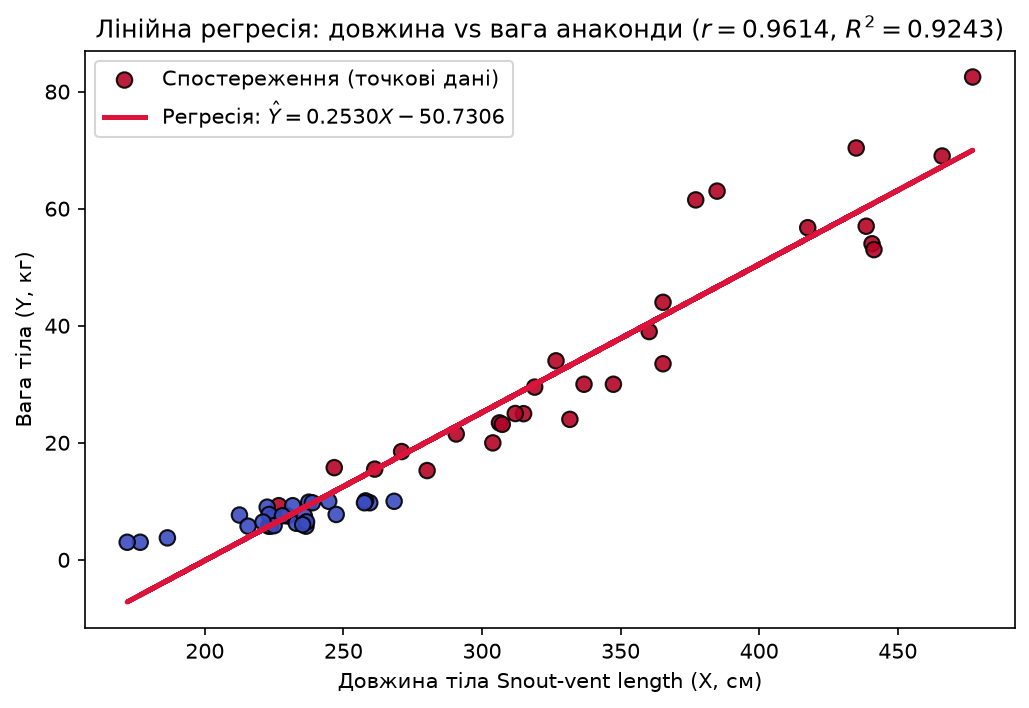

In [5]:
# Побудова графіка регресії
plt.figure(figsize=(8, 5))
plt.scatter(df['X'], df['Y'], c=df['Gender_code'], cmap='coolwarm', s=55, alpha=0.9, edgecolors='k', label='Спостереження (точкові дані)')
plt.plot(df['X'], Y_pred, color='crimson', linewidth=2.4, label=f'Регресія: $\\hat{{Y}} = {slope:.4f}X - {-intercept:.4f}$')
plt.title(f'Лінійна регресія: довжина vs вага анаконди ($r = {r_xy:.4f}$, $R^2 = {r2:.4f}$)')
plt.xlabel('Довжина тіла Snout-vent length (X, см)')
plt.ylabel('Вага тіла (Y, кг)')
plt.legend(frameon=True)
plt.show()

## 6. Аналіз та діагностика залишків (Diagnostic Plots)
**Мета дії:** Обчислити нев'язки (залишки) $e_i = Y_i - \hat{Y}_i$, перевірити виконання умов лінійності, нульового математичного сподівання, гомоскедастичності та нормального розподілу помилок.
$$\rightarrow$$ **Висновок:** Середнє залишків практично нульове ($-8.44 \cdot 10^{-15}$). Проте U-подібна форма залишків та тест Шапіро-Уїлка ($p = 9.67 \cdot 10^{-4} < 0.05$) свідчать про порушення гомоскедастичності та нелінійний характер реальної залежності.

Середнє арифметичне залишків: -8.44e-15
Критерій Шапіро-Уїлка: W = 0.9176, p-value = 9.6736e-04


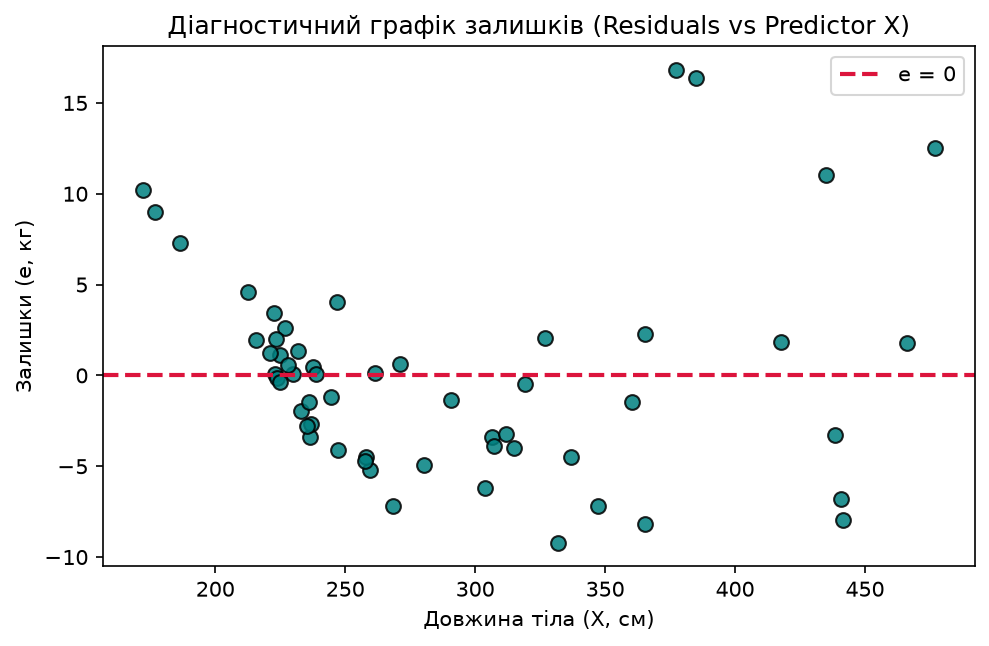

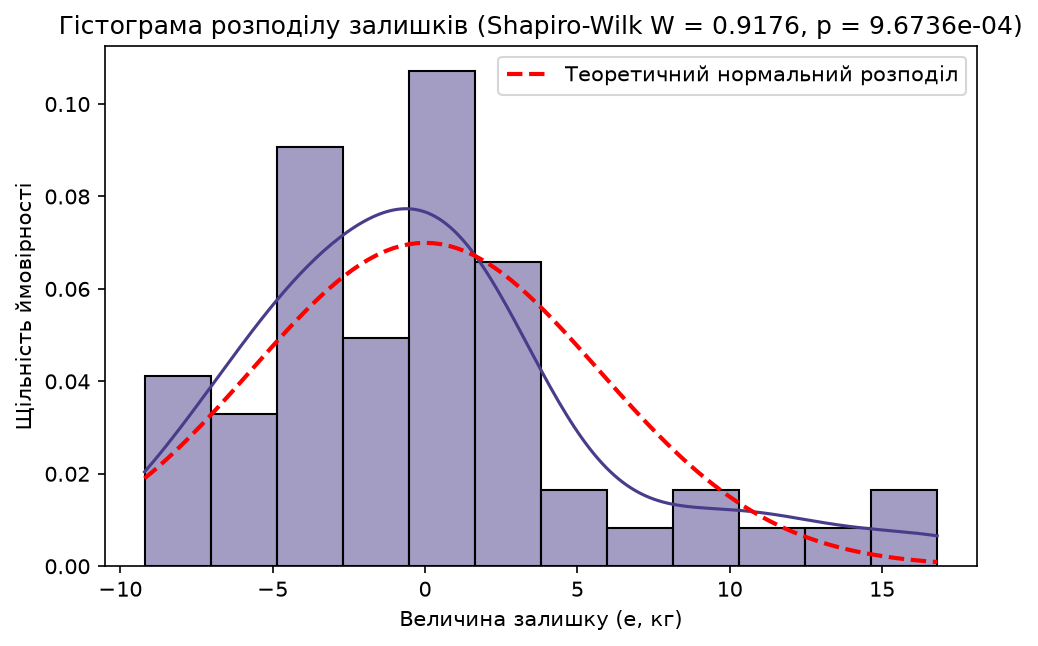

In [6]:
residuals = Y - Y_pred
res_mean = np.mean(residuals)
shapiro_w, shapiro_p = stats.shapiro(residuals)

print(f'Середнє арифметичне залишків: {res_mean:.2e}')
print(f'Критерій Шапіро-Уїлка: W = {shapiro_w:.4f}, p-value = {shapiro_p:.4e}')

# 1. Графік залишків від предиктора
plt.figure(figsize=(7.5, 4.5))
plt.scatter(df['X'], residuals, color='teal', s=50, alpha=0.85, edgecolors='k')
plt.axhline(0, color='crimson', linestyle='--', linewidth=2, label='e = 0')
plt.title('Діагностичний графік залишків (Residuals vs Predictor X)')
plt.xlabel('Довжина тіла (X, см)')
plt.ylabel('Залишки (e, кг)')
plt.legend(frameon=True)
plt.show()

# 2. Гістограма розподілу залишків
plt.figure(figsize=(7.5, 4.5))
sns.histplot(residuals, kde=True, color='darkslateblue', bins=12, stat='density', edgecolor='black')
norm_x = np.linspace(np.min(residuals), np.max(residuals), 100)
norm_y = stats.norm.pdf(norm_x, loc=np.mean(residuals), scale=np.std(residuals, ddof=1))
plt.plot(norm_x, norm_y, 'r--', linewidth=2, label='Теоретичний нормальний розподіл')
plt.title(f'Гістограма розподілу залишків (Shapiro-Wilk W = {shapiro_w:.4f}, p = {shapiro_p:.4e})')
plt.xlabel('Величина залишку (e, кг)')
plt.ylabel('Щільність ймовірності')
plt.legend(frameon=True)
plt.show()

## 7. Дослідження власного числового набору даних (Частина 2: Advertising.csv)
**Мета дії:** Дослідити лінійну залежність між обсягом витрат на телевізійну рекламу (тис. USD) та кількістю проданої продукції (тис. од.), оцінити силу зв'язку через коефіцієнт кореляції Пірсона, побудувати модель лінійної регресії та результуючий графік.

→ **Висновок:** Виявлено стійку статистично значущу лінійну кореляцію ($r = 0.7822$, $p = 1.47 \times 10^{-42}$); парна лінійна модель пояснює 61.19% дисперсії продажів ($R^2 = 0.6119$, RMSE = 3.24 тис. од.).

Кількість спостережень: 200
Коефіцієнт кореляції Пірсона r = 0.7822, p-value = 1.4674e-42
Рівняння: Sales = 0.0475 * TV + 7.03
Коефіцієнт детермінації R^2 = 0.6119
RMSE = 3.24 тис. од.


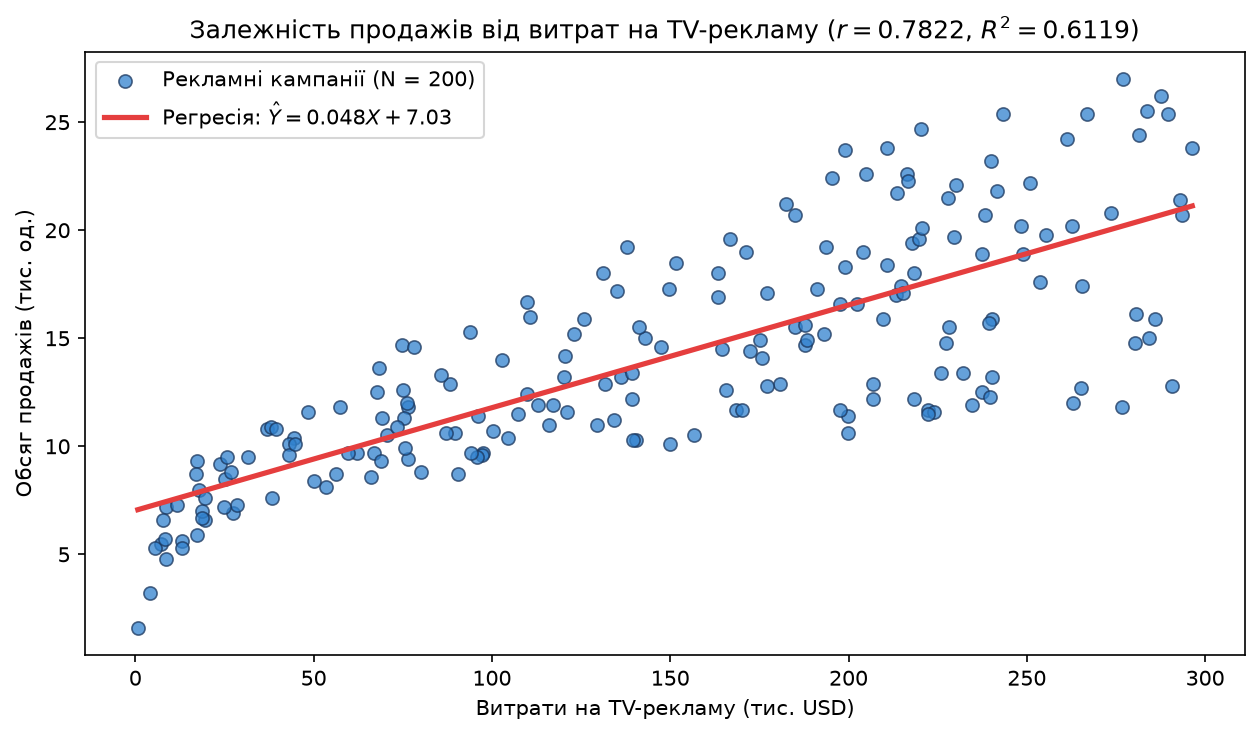

In [7]:
# Завантаження даних витрат на рекламу та продажів
import urllib.request
adv_file = 'Advertising.csv'
if not os.path.exists(adv_file):
    url = 'https://raw.githubusercontent.com/justmarkham/scikit-learn-videos/master/data/Advertising.csv'
    urllib.request.urlretrieve(url, adv_file)

df_adv = pd.read_csv(adv_file)
tv = pd.to_numeric(df_adv['TV'], errors='coerce')
sales = pd.to_numeric(df_adv['Sales'], errors='coerce')
valid_mask = tv.notna() & sales.notna()
df_clean = pd.DataFrame({'TV': tv[valid_mask], 'Sales': sales[valid_mask]})
print(f'Кількість спостережень: {len(df_clean)}')

# Кореляційний аналіз
r_val, p_val = stats.pearsonr(df_clean['TV'], df_clean['Sales'])
print(f'Коефіцієнт кореляції Пірсона r = {r_val:.4f}, p-value = {p_val:.4e}')

# Лінійна регресія
X_c = df_clean[['TV']].values
Y_c = df_clean['Sales'].values
model_adv = LinearRegression().fit(X_c, Y_c)
Y_pred_c = model_adv.predict(X_c)

slope_c = float(model_adv.coef_[0])
intercept_c = float(model_adv.intercept_)
r2_c = r2_score(Y_c, Y_pred_c)
rmse_c = np.sqrt(mean_squared_error(Y_c, Y_pred_c))

print(f'Рівняння: Sales = {slope_c:.4f} * TV + {intercept_c:.2f}')
print(f'Коефіцієнт детермінації R^2 = {r2_c:.4f}')
print(f'RMSE = {rmse_c:.2f} тис. од.')

# Візуалізація
plt.figure(figsize=(8.5, 5))
plt.scatter(df_clean['TV'], df_clean['Sales'], color='#3182ce', alpha=0.75, s=40, edgecolors='#1a365d', linewidth=0.8, label=f'Рекламні кампанії (N = {len(df_clean)}')
s_idx = np.argsort(df_clean['TV'].values)
plt.plot(df_clean['TV'].values[s_idx], Y_pred_c[s_idx], color='#e53e3e', linewidth=2.5,
         label=rf'Регресія: $\\hat{{Y}} = {slope_c:.3f}X + {intercept_c:.2f}$')
plt.title(f'Залежність продажів від витрат на TV-рекламу ($r = {r_val:.4f}$, $R^2 = {r2_c:.4f}$)')
plt.xlabel('Витрати на TV-рекламу (тис. USD)')
plt.ylabel('Обсяг продажів (тис. од.)')
plt.legend(frameon=True, loc='upper left')
plt.tight_layout()
plt.show()

## 8. Загальний висновок
У ході лабораторної роботи було досліджено властивості лінійного кореляційного та регресійного аналізу:
1. **Датасет anaconda.dat:** виявлено майже функціональний лінійний зв'язок між довжиною тіла та вагою ($r = 0.9614, R^2 = 0.9243$). Проте діагностичний аналіз залишків продемонстрував їх гетероскедастичність та нелінійний U-подібний характер, що узгоджується з кубічним зростанням об'єму тіла тварини.
2. **Власний датасет (Advertising.csv):** підтверджено наявність стійкої лінійної залежності між витратами на TV-рекламу та обсягом збуту ($r = 0.7822, p = 1.47 \times 10^{-42}$); модель пояснює 61.19% варіації продажів ($R^2 = 0.6119$, RMSE = 3.24 тис. од.).
3. Освоєно повний цикл побудови регресійних моделей у Python за допомогою `pandas`, `scipy.stats` та `scikit-learn`.